In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import boto3
import sagemaker

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
sess = sagemaker.Session()
bucket = sess.default_bucket()

In [3]:
s3_train_test_data_prefix = 'final_project/train-test-splits'

#Load data train data
train_df = pd.read_csv(f"s3://{bucket}/{s3_train_test_data_prefix}/Xy_train.csv")

# Check for NaNs and drop or fill
train_df.dropna(inplace=True)

In [4]:
#Load data test data
test_df = pd.read_csv(f"s3://{bucket}/{s3_train_test_data_prefix}/Xy_test.csv")

# Check for NaNs and drop or fill
test_df.dropna(inplace=True)

In [5]:
train_df.columns

Index(['subflow_fwd_bytes', 'fwd_packet_length_mean',
       'fwd_packets_length_total', 'avg_fwd_segment_size',
       'fwd_act_data_packets', 'fwd_packet_length_max', 'fwd_iat_std',
       'init_fwd_win_bytes', 'fwd_header_length', 'subflow_fwd_packets',
       'record_id', 'event_time', 'label'],
      dtype='object')

In [6]:
train_df.dtypes

subflow_fwd_bytes             int64
fwd_packet_length_mean      float64
fwd_packets_length_total      int64
avg_fwd_segment_size        float64
fwd_act_data_packets          int64
fwd_packet_length_max         int64
fwd_iat_std                 float64
init_fwd_win_bytes            int64
fwd_header_length             int64
subflow_fwd_packets           int64
record_id                    object
event_time                  float64
label                         int64
dtype: object

In [7]:
train_df = train_df.drop(['record_id', 'event_time'], axis=1)
test_df = test_df.drop(['record_id', 'event_time'], axis=1)

In [8]:
test_df.columns

Index(['subflow_fwd_bytes', 'fwd_packet_length_mean',
       'fwd_packets_length_total', 'avg_fwd_segment_size',
       'fwd_act_data_packets', 'fwd_packet_length_max', 'fwd_iat_std',
       'init_fwd_win_bytes', 'fwd_header_length', 'subflow_fwd_packets',
       'label'],
      dtype='object')

In [9]:
y = train_df['label']
X = train_df.drop('label', axis=1)

In [10]:
# Train a shallow decision tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [11]:
X.columns

Index(['subflow_fwd_bytes', 'fwd_packet_length_mean',
       'fwd_packets_length_total', 'avg_fwd_segment_size',
       'fwd_act_data_packets', 'fwd_packet_length_max', 'fwd_iat_std',
       'init_fwd_win_bytes', 'fwd_header_length', 'subflow_fwd_packets'],
      dtype='object')

In [12]:
from sklearn.tree import export_text
#  Display the decision tree rules
tree_rules = export_text(clf, feature_names=X.columns)
print("Extracted Decision Rules:\n")
print(tree_rules)

Extracted Decision Rules:

|--- fwd_packet_length_max <= 21.00
|   |--- fwd_packets_length_total <= 19.00
|   |   |--- subflow_fwd_bytes <= 15.00
|   |   |   |--- class: 0
|   |   |--- subflow_fwd_bytes >  15.00
|   |   |   |--- class: 0
|   |--- fwd_packets_length_total >  19.00
|   |   |--- init_fwd_win_bytes <= 255.00
|   |   |   |--- class: 0
|   |   |--- init_fwd_win_bytes >  255.00
|   |   |   |--- class: 1
|--- fwd_packet_length_max >  21.00
|   |--- class: 0



In [13]:
# Define heuristic with the thresholds

fwd_packet_length_max = 21.0
subflow_fwd_bytes = 19
init_fwd_win_bytes = 255.5

def intrusion_detection_heuristic(row):
    if row['fwd_packet_length_max'] <= fwd_packet_length_max:
        if row['subflow_fwd_bytes'] > subflow_fwd_bytes:
            if row['init_fwd_win_bytes'] > init_fwd_win_bytes:
                return 1  # Intrusion
            else:
                return 0  # Benign
        else:  # fwd_packets_length_total > FwdPacketLengthTotal
            return 0  # Benign
    else:  # fwd_packet_length_max > FwdPacketLengthMax
        return 0  # Benign

In [14]:
# Apply heuristic
test_df['heuristic_pred'] = test_df.apply(intrusion_detection_heuristic, axis=1)


🔍 Classification Report for Heuristic Function:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9232
           1       1.00      1.00      1.00     12674

    accuracy                           1.00     21906
   macro avg       1.00      1.00      1.00     21906
weighted avg       1.00      1.00      1.00     21906


📉 Confusion Matrix:



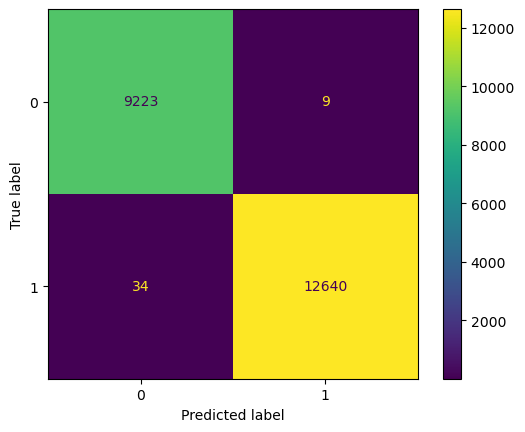

In [15]:
#  Evaluate heuristic performance
print("\n🔍 Classification Report for Heuristic Function:\n")
print(classification_report(test_df['label'], test_df['heuristic_pred']))

print("\n📉 Confusion Matrix:\n")
ConfusionMatrixDisplay.from_predictions(test_df['label'], test_df['heuristic_pred'])
plt.show()